In [1]:
!pip install ultralytics

In [2]:
from ultralytics import YOLO
from collections import Counter

import cv2
import matplotlib.pyplot as plt


image 1/1 c:\dl\test\yolo data\12345.jpg: 640x480 6 persons, 6 cars, 1 truck, 6 handbags, 1 potted plant, 89.7ms
Speed: 2.7ms preprocess, 89.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


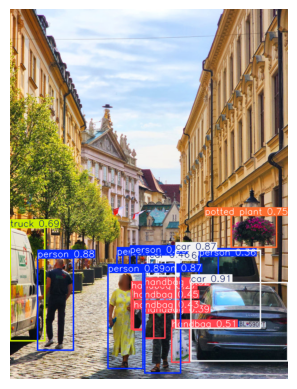

car: 6
person: 6
potted plant: 1
truck: 1
handbag: 6


In [3]:
model = YOLO('models/yolov8s.pt')

results = model('test/yolo data/12345.jpg')
r = results[0]

plots = r.plot()
plots = cv2.cvtColor(plots, cv2.COLOR_BGR2RGB)

plt.imshow(plots)
plt.axis('off')
plt.show()

class_ids = r.boxes.cls.tolist()

class_names = [r.names[int(cls_id)] for cls_id in class_ids]

count_results = Counter(class_names)

for name, count in count_results.items():
    print(f"{name}: {count}")

In [4]:
print(model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

### 사람 (0.5이상 , 갯수 구하기)


image 1/1 c:\dl\test\yolo data\12345.jpg: 640x480 6 persons, 6 cars, 1 truck, 6 handbags, 1 potted plant, 66.9ms
Speed: 2.6ms preprocess, 66.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)


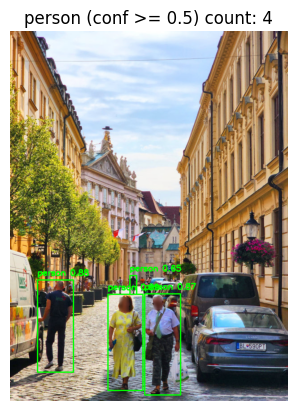

In [5]:
model = YOLO('models/yolov8s.pt')

results = model('test/yolo data/12345.jpg')
r = results[0]

img = r.orig_img.copy()
names = r.names

conf_th = 0.5
person_count = 0

for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
    class_name = names[int(cls)]
    conf = float(conf)

    if class_name == "person" and conf >= conf_th:
        x1, y1, x2, y2 = map(int, box)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f'{class_name} {conf:.2f}'

        cv2.putText(img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        person_count += 1

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.title(f"person (conf >= 0.5) count: {person_count}")
plt.show()

In [6]:
from ultralytics import YOLO
import cv2

model = YOLO('models/yolov8s.pt')

cap = cv2.VideoCapture(r"C:\dl\test\yolo data\people_walk.mp4")

conf_th = 0.5

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.resize(frame, (640, 360))

    results = model.track(frame, persist=True, conf=conf_th)

    result = results[0]
    names = result.names
    img = frame.copy()

    if result.boxes is not None and result.boxes.id is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        classes = result.boxes.cls.cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()
        track_ids = result.boxes.id.cpu().tolist()

        for box, cls, conf, track_id in zip(boxes, classes, confs, track_ids):
            class_name = names[int(cls)]

            if class_name == "person" and conf >= conf_th:
                x1, y1, x2, y2 = map(int, box)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                label = f'ID:{track_id} {conf:.2f}'

                cv2.putText(img, label, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    cv2.imshow("Tracking", img)

    if cv2.waitKey(1) & 0xff == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


0: 384x640 8 persons, 1 handbag, 68.4ms
Speed: 1.3ms preprocess, 68.4ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 49.5ms
Speed: 1.5ms preprocess, 49.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 1 handbag, 53.5ms
Speed: 1.7ms preprocess, 53.5ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 1 handbag, 52.3ms
Speed: 1.4ms preprocess, 52.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 1 handbag, 50.4ms
Speed: 1.5ms preprocess, 50.4ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 1 handbag, 50.4ms
Speed: 1.6ms preprocess, 50.4ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 51.6ms
Speed: 1.3ms preprocess, 51.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 55.4ms
Speed: 1.4ms preprocess, 5


image 1/1 c:\dl\test\yolo data\handbag_02.jpg: 416x640 6 persons, 2 cars, 6 handbags, 67.2ms
Speed: 1.1ms preprocess, 67.2ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 640)


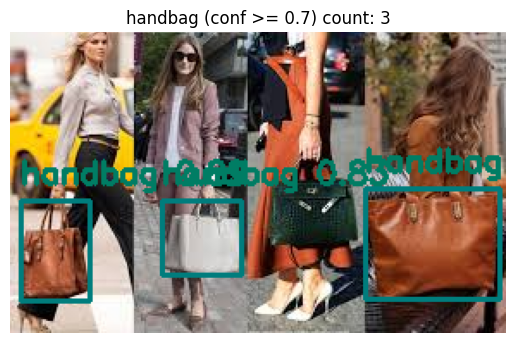

In [7]:
model = YOLO('models/yolov8s.pt')

results = model("test/yolo data/handbag_02.jpg")
r = results[0]

img = r.orig_img.copy()
names = r.names

conf_th = 0.7
handbag_count = 0

for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
    class_name = names[int(cls)]
    conf = float(conf)

    if class_name == "handbag" and conf >= conf_th:
        x1, y1, x2, y2 = map(int, box)

        cv2.rectangle(img, (x1, y1), (x2, y2), (125, 125, 0), 2)
        label = f'{class_name} {conf:.2f}'

        cv2.putText(img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (100, 125, 0), 2)

        handbag_count += 1

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.title(f"handbag (conf >= 0.7) count: {handbag_count}")
plt.show()